# Praktikum 4 – Image Enhancement dengan Mask Processing
- **Versi 1**: inverted clipping → sesuai *expected output*
- **Versi 2**: normal clipping → output gelap/hitam

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

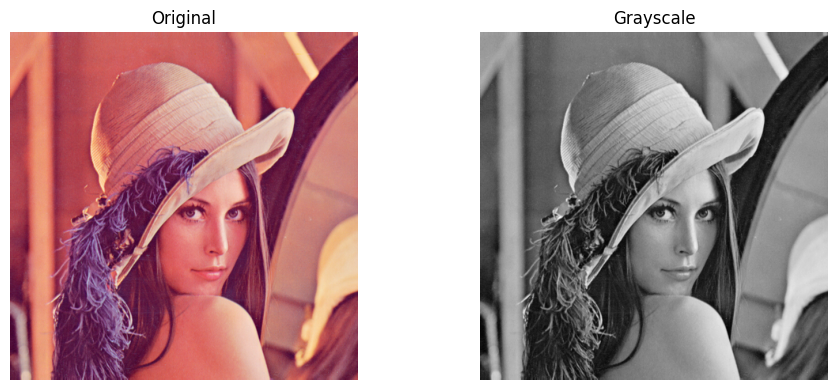

In [2]:
img_lenna = cv2.imread('lenna.png')

B = img_lenna[:,:,0]
G = img_lenna[:,:,1]
R = img_lenna[:,:,2]
Y = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img_lenna, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(Y, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [3]:
low_pass_kernel = np.array([[1, 1, 1],
                            [1, 1, 1],
                            [1, 1, 1]], dtype=np.float32)

high_pass_kernel = np.array([[0, -1,  0],
                             [-1,  4, -1],
                             [0, -1,  0]], dtype=np.float32)

directional_kernel = np.array([[1, 0, -1],
                               [1, 0, -1],
                               [1, 0, -1]], dtype=np.float32)

## Versi 1 – Inverted Clipping
Nilai negatif → 255 (putih), sehingga kedua sisi edge terlihat.

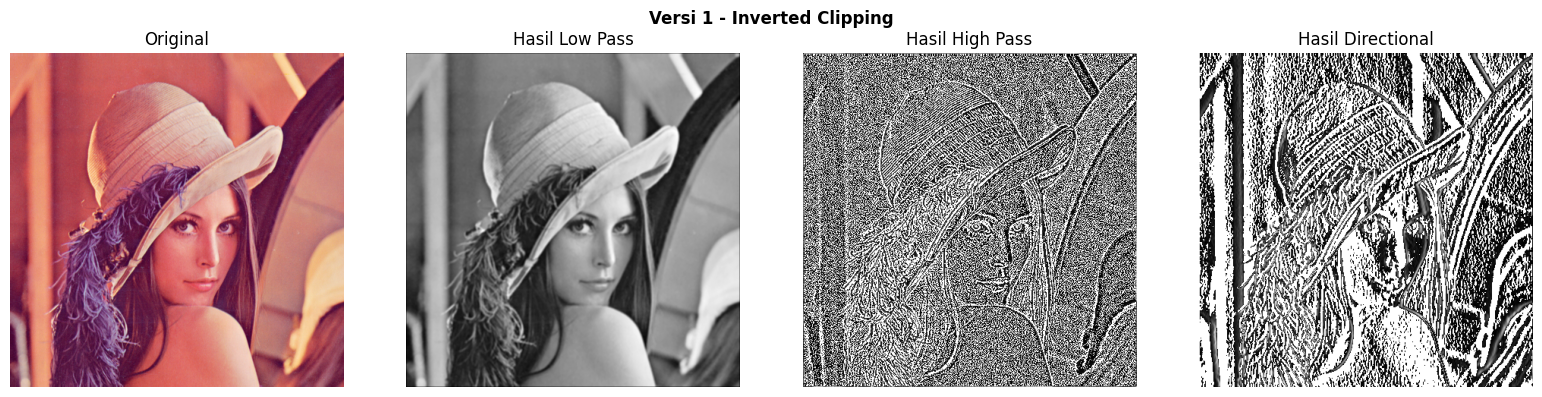

In [4]:
def customConvolution(image, mask):
    row, col = image.shape
    m_row, m_col = mask.shape
    offset_i = m_row // 2
    offset_j = m_col // 2

    result = np.zeros((row, col), dtype=np.uint8)
    maskSum = np.sum(mask)

    for i in range(row):
        for j in range(col):
            imageSum = 0.0
            for a in range(-offset_i, m_row - offset_i):
                for b in range(-offset_j, m_col - offset_j):
                    if (0 <= i+a < row) and (0 <= j+b < col):
                        imageSum += image[i+a, j+b] * mask[a+offset_i, b+offset_j]

            if maskSum != 0:
                intensity = imageSum / maskSum
            else:
                intensity = imageSum

            if intensity > 255: intensity = 0
            elif intensity < 0: intensity = 255

            result[i, j] = intensity

    return result

hasil_low1  = customConvolution(Y, low_pass_kernel)
hasil_high1 = customConvolution(Y, high_pass_kernel)
hasil_dir1  = customConvolution(Y, directional_kernel)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(img_lenna, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original')
axes[1].imshow(hasil_low1, cmap='gray');  axes[1].set_title('Hasil Low Pass')
axes[2].imshow(hasil_high1, cmap='gray'); axes[2].set_title('Hasil High Pass')
axes[3].imshow(hasil_dir1, cmap='gray');  axes[3].set_title('Hasil Directional')
for ax in axes: ax.axis('off')
plt.suptitle('Versi 1 - Inverted Clipping', fontweight='bold')
plt.tight_layout()
plt.show()

## Versi 2 – Normal Clipping
Nilai negatif → 0 (hitam), high pass & directional jadi dominan gelap.

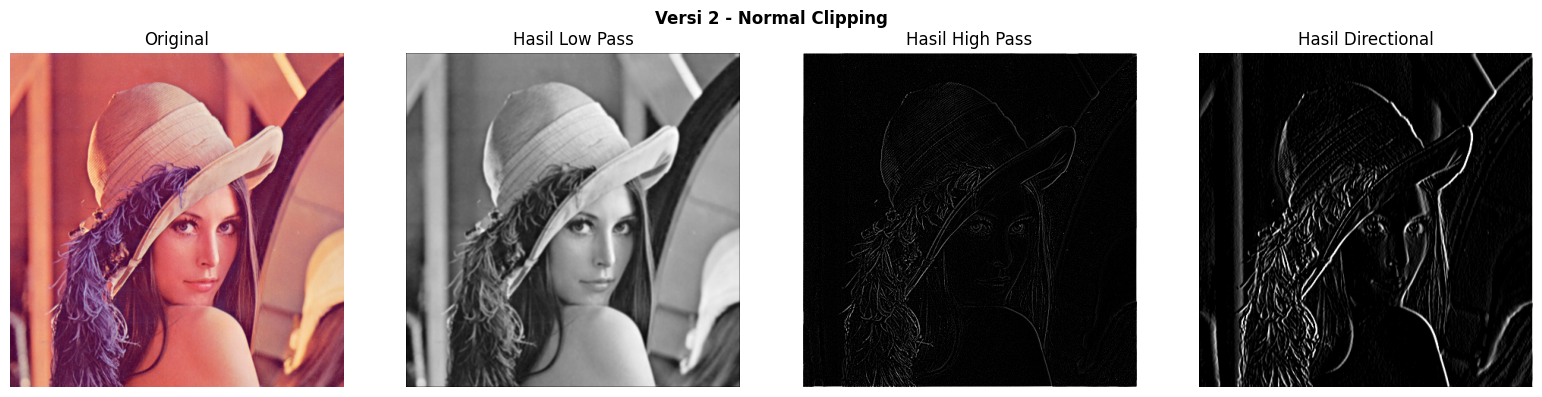

In [5]:
def customConvolution(image, mask):
    row, col = image.shape
    m_row, m_col = mask.shape
    offset_i = m_row // 2
    offset_j = m_col // 2

    result = np.zeros((row, col), dtype=np.uint8)
    maskSum = np.sum(mask)

    for i in range(row):
        for j in range(col):
            imageSum = 0.0
            for a in range(-offset_i, m_row - offset_i):
                for b in range(-offset_j, m_col - offset_j):
                    if (0 <= i+a < row) and (0 <= j+b < col):
                        imageSum += image[i+a, j+b] * mask[a+offset_i, b+offset_j]

            if maskSum != 0:
                intensity = imageSum / maskSum
            else:
                intensity = imageSum

            if intensity > 255: intensity = 255
            elif intensity < 0: intensity = 0

            result[i, j] = intensity

    return result

hasil_low2  = customConvolution(Y, low_pass_kernel)
hasil_high2 = customConvolution(Y, high_pass_kernel)
hasil_dir2  = customConvolution(Y, directional_kernel)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(img_lenna, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original')
axes[1].imshow(hasil_low2, cmap='gray');  axes[1].set_title('Hasil Low Pass')
axes[2].imshow(hasil_high2, cmap='gray'); axes[2].set_title('Hasil High Pass')
axes[3].imshow(hasil_dir2, cmap='gray');  axes[3].set_title('Hasil Directional')
for ax in axes: ax.axis('off')
plt.suptitle('Versi 2 - Normal Clipping', fontweight='bold')
plt.tight_layout()
plt.show()